In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ Estilo aplicado AL INICIO
plt.style.use('seaborn-v0_8-whitegrid')

# Cargar datos
df_plot = pd.read_csv('../outputs/tablas/02_ajustes_completos.csv', sep=';')
x = df_plot['edad'].values
y = df_plot['tiempo_real'].values

# ==========================================
# RECALCULAR MODELOS (para obtener coeficientes y ecuaciones)
# ==========================================

# 1. Lineal
A_lin = np.vstack([x, np.ones(len(x))]).T
m_lin, c_lin = np.linalg.lstsq(A_lin, y, rcond=None)[0]

# 2. Cuadrático
A_cuad = np.vstack([x**2, x, np.ones(len(x))]).T
a_cuad, b_cuad, c_cuad = np.linalg.lstsq(A_cuad, y, rcond=None)[0]

# 3. Cúbico
A_cub = np.vstack([x**3, x**2, x, np.ones(len(x))]).T
a_cub, b_cub, c_cub, d_cub = np.linalg.lstsq(A_cub, y, rcond=None)[0]

# 4. Exponencial
A_exp = np.vstack([x, np.ones(len(x))]).T
m_exp, ln_c_exp = np.linalg.lstsq(A_exp, np.log(y), rcond=None)[0]
c_exp = np.exp(ln_c_exp)

# 5. Logarítmico
A_log = np.vstack([np.log(x), np.ones(len(x))]).T
m_log, c_log = np.linalg.lstsq(A_log, y, rcond=None)[0]

# ==========================================
# ECUACIONES COMO TEXTO (para mostrar en gráficas)
# ==========================================
eq_lineal = f"y = {m_lin:.3f}x + {c_lin:.2f}"
eq_cuad   = f"y = {a_cuad:.5f}x² + {b_cuad:.3f}x + {c_cuad:.2f}"
eq_cub    = f"y = {a_cub:.6f}x³ + {b_cub:.4f}x² + {c_cub:.3f}x + {d_cub:.2f}"
eq_exp    = f"y = {c_exp:.2f}·e^({m_exp:.4f}x)"
eq_log    = f"y = {m_log:.2f}·ln(x) + {c_log:.2f}"

# Función para calcular R²
def calcular_r2(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred)**2)
    ss_tot = np.sum((y_real - np.mean(y_real))**2)
    return 1 - (ss_res / ss_tot)

# Estructura de modelos: (título, columna_csv, color, ecuación)
modelos = [
    ('Modelo Lineal',      'ajuste_lineal',      'red',    eq_lineal),
    ('Modelo Cuadrático',  'ajuste_cuadratico',  'blue',   eq_cuad),
    ('Modelo Cúbico',      'ajuste_cubico',      'green',  eq_cub),
    ('Modelo Exponencial', 'ajuste_exponencial', 'purple', eq_exp),
    ('Modelo Logarítmico', 'ajuste_logaritmico', 'orange', eq_log),
]

# R² de cada modelo
r2_scores = {titulo: calcular_r2(y, df_plot[col]) for titulo, col, _, _ in modelos}

# Mostrar resumen
print("📊 Resumen de modelos:")
for titulo, _, _, eq in modelos:
    print(f"  {titulo:22s} → R² = {r2_scores[titulo]:.4f}")
    print(f"  {'':22s}   {eq}")

📊 Resumen de modelos:
  Modelo Lineal          → R² = 0.1877
                           y = 4.609x + -34.50
  Modelo Cuadrático      → R² = 0.2072
                           y = -0.09891x² + 13.525x + -216.50
  Modelo Cúbico          → R² = 0.2121
                           y = -0.003347x³ + 0.3628x² + -6.297x + 46.84
  Modelo Exponencial     → R² = -0.0337
                           y = 21.14·e^(0.0340x)
  Modelo Logarítmico     → R² = 0.2004
                           y = 196.30·ln(x) + -564.48


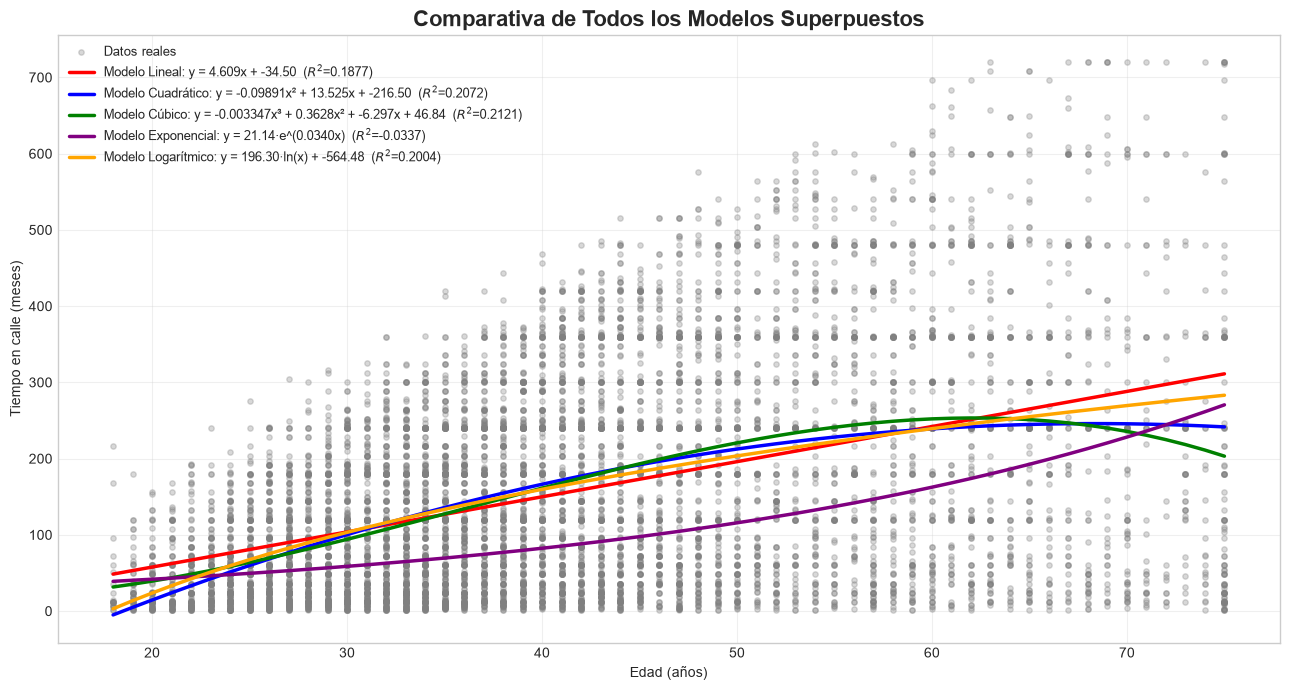

In [18]:
# ==========================================
# GRÁFICA COMPARATIVA SUPERPUESTA
# ==========================================
plt.figure(figsize=(13, 7))
plt.scatter(x, y, color='gray', alpha=0.3, label='Datos reales', s=15)

for titulo, columna, color, eq in modelos:
    r2 = r2_scores[titulo]
    plt.plot(x, df_plot[columna], color=color, linewidth=2.5,
             label=f'{titulo}: {eq}  ($R^2$={r2:.4f})')

plt.title('Comparativa de Todos los Modelos Superpuestos',
          fontsize=16, fontweight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Tiempo en calle (meses)')
plt.legend(fontsize=9, loc='upper left', framealpha=0.95)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../outputs/figuras/03_comparativa_superpuesta.png',
            dpi=300, bbox_inches='tight')
plt.show()

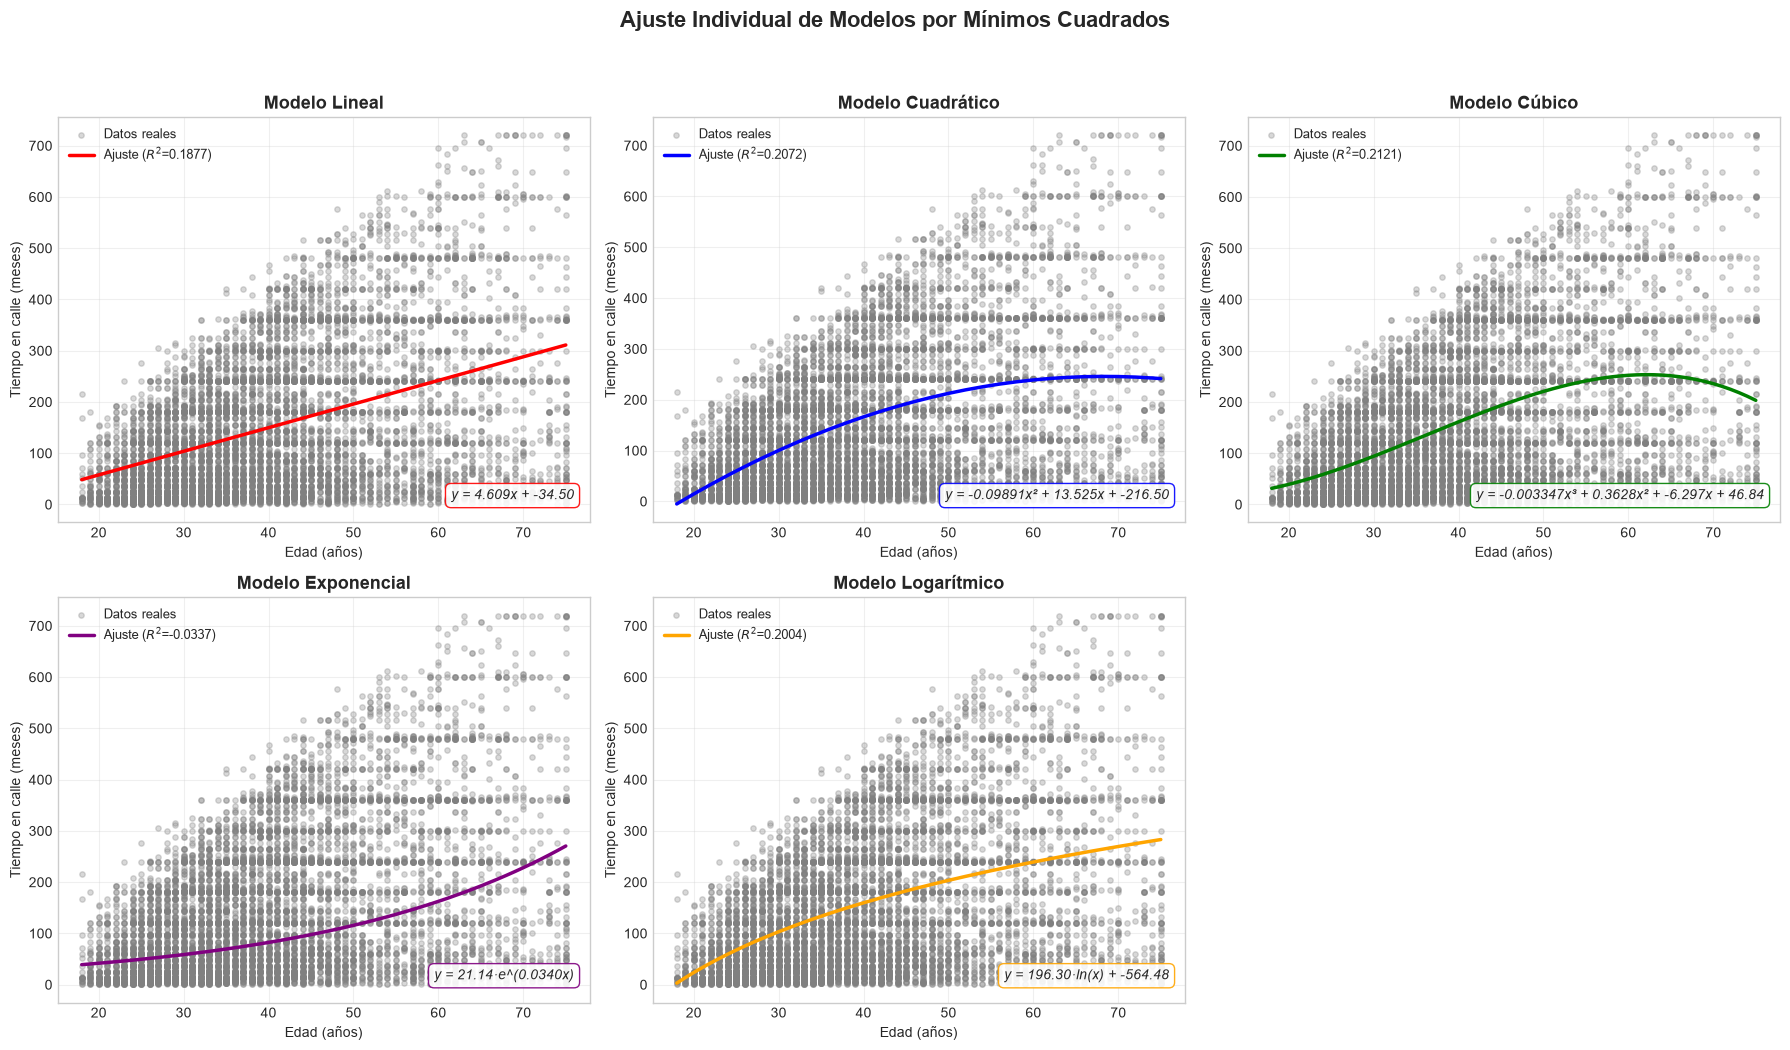

In [19]:
# ==========================================
# MATRIZ DE SUBPLOTS INDIVIDUALES
# ==========================================
fig, axs = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Ajuste Individual de Modelos por Mínimos Cuadrados',
             fontsize=16, fontweight='bold')

axs = axs.flatten()

for i, (titulo, columna, color, eq) in enumerate(modelos):
    ax = axs[i]
    r2 = r2_scores[titulo]

    ax.scatter(x, y, color='gray', alpha=0.3, s=15, label='Datos reales')
    ax.plot(x, df_plot[columna], color=color, linewidth=2.5,
            label=f'Ajuste ($R^2$={r2:.4f})')

    # Título con el nombre del modelo
    ax.set_title(titulo, fontsize=13, fontweight='bold')

    # ✅ ECUACIÓN dentro del gráfico (esquina inferior derecha)
    ax.text(0.97, 0.05, eq,
            transform=ax.transAxes,
            fontsize=10,
            fontstyle='italic',
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white',
                      edgecolor=color,
                      alpha=0.9))

    ax.set_xlabel('Edad (años)')
    ax.set_ylabel('Tiempo en calle (meses)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')

# Ocultar el sexto cuadrante vacío
axs[5].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../outputs/figuras/03_subplots_individuales.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# ==========================================
# TABLA RESUMEN CON ECUACIONES
# ==========================================
df_resultados = pd.DataFrame({
    'Modelo':    [t for t, _, _, _ in modelos],
    'Ecuación':  [eq for _, _, _, eq in modelos],
    'R²':        [round(r2_scores[t], 4) for t, _, _, _ in modelos]
})

# Ordenar de mejor a peor
df_resultados = df_resultados.sort_values('R²', ascending=False).reset_index(drop=True)
df_resultados.index = df_resultados.index + 1

print("🏆 Ranking de modelos por R²:\n")
for i, row in df_resultados.iterrows():
    print(f"{i}. {row['Modelo']:22s}  R² = {row['R²']:.4f}")
    print(f"   {row['Ecuación']}\n")

# Guardar
df_resultados.to_csv('../outputs/tablas/03_ranking_modelos.csv',
                     index=False, sep=';')
print("✅ Guardado en: outputs/tablas/03_ranking_modelos.csv")

🏆 Ranking de modelos por R²:

1. Modelo Cúbico           R² = 0.2121
   y = -0.003347x³ + 0.3628x² + -6.297x + 46.84

2. Modelo Cuadrático       R² = 0.2072
   y = -0.09891x² + 13.525x + -216.50

3. Modelo Logarítmico      R² = 0.2004
   y = 196.30·ln(x) + -564.48

4. Modelo Lineal           R² = 0.1877
   y = 4.609x + -34.50

5. Modelo Exponencial      R² = -0.0337
   y = 21.14·e^(0.0340x)

✅ Guardado en: outputs/tablas/03_ranking_modelos.csv


## 📊 Análisis de Resultados y Conclusiones

> **Contexto:** Análisis derivado del ajuste por Mínimos Cuadrados Ordinarios aplicado a los microdatos del *VIII Censo de Habitantes de Calle (Bogotá, 2024)*.

---

### 🥇 1. ¿Cuál es el modelo con mejor ajuste y cómo se comparan?
Al evaluar el coeficiente de determinación ($R^2$), el rendimiento de los modelos se divide claramente:

* **Los mejores ajustes:** El **Modelo Cúbico** y el **Modelo Cuadrático** lideran con un $R^2 \approx 0.21$. Logran adaptarse mejor a la curvatura natural de los datos, especialmente al estancamiento del tiempo en calle en edades avanzadas.
* **Ajustes deficientes:** Los modelos Lineal y Logarítmico son demasiado rígidos y subestiman el crecimiento en las etapas medias de la vida.
* **El modelo descartado:** El Modelo Exponencial fracasa por completo ($R^2 < 0$), lo que demuestra matemáticamente que el tiempo de permanencia en la calle **no crece de forma multiplicativa** con la edad.

### 📉 2. ¿Por qué las curvas no "alcanzan" los datos más altos en la gráfica?
A simple vista parece que la curva se queda "muy abajo" frente a los puntos superiores (personas con 500-700 meses en calle), pero esto tiene una justificación matemática rigurosa:

1. **Centro de Gravedad:** El método de mínimos cuadrados minimiza los errores globales. La abrumadora mayoría de la población (la franja gris oscura) lleva menos de 100 meses en calle. 
2. **Tratamiento de Valores Atípicos:** Los valores superiores actúan como *outliers* (anomalías estadísticas). El modelo "tira" la línea hacia donde está concentrada la verdadera masa poblacional, reflejando correctamente el comportamiento de la mayoría y no de las excepciones.

### 🧩 3. ¿Qué conclusiones se obtienen sobre la naturaleza de la base de datos?
Nuestro mejor modelo obtiene un $R^2 = 0.21$. Esto significa que la variable "edad" **solo explica el 21% de la variabilidad** del tiempo en situación de calle. Lejos de ser un fallo del algoritmo, esto revela la verdadera naturaleza del fenómeno:
* Es un problema **altamente multidimensional**.
* El **79% de la varianza restante** recae en factores que este modelo bidimensional no incluyó (como el consumo de sustancias psicoactivas, el nivel educativo o las redes familiares).

---

### 💡 Conclusión y Recomendación

El álgebra lineal, mediante las ecuaciones normales, nos permitió proyectar la mejor aproximación matemática posible en un espacio de dos dimensiones. Sin embargo, para fines de política pública, el Distrito debería escalar este análisis hacia **modelos de regresión múltiple**. Integrar el resto de dimensiones sociales de la encuesta permitiría crear un **Índice de Vulnerabilidad** mucho más preciso para focalizar la atención institucional.